In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

In [21]:
arr =xr.open_dataset(f"../Sens_Output_agg.nc")
arr

<xarray.Dataset> Size: 3MB
Dimensions:           (run_id: 50000, tree_rmse_id: 14)
Coordinates:
  * run_id            (run_id) int64 400kB 0 1 2 3 4 ... 6246 6247 6248 6249
  * tree_rmse_id      (tree_rmse_id) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    RMSE_swiss_trees  (run_id, tree_rmse_id) float32 3MB ...

In [34]:
np.min(arr['RMSE_swiss_trees'][:,:].values, axis= 0)

array([1.0022391 , 0.41003576, 1.1054429 , 0.88588303, 0.5425275 ,
       0.00471233, 1.6820769 , 1.3706111 , 0.03690837, 0.11107089,
       0.5287991 , 0.45696566, 0.54598445, 0.52165157], dtype=float32)

In [38]:
np.quantile(arr['RMSE_swiss_trees'][:,:].values, axis= 0, q = 0.01)

array([1.17302017, 0.82463216, 1.55559051, 1.00233042, 0.85615522,
       0.30182696, 1.70986016, 1.54472909, 0.62016908, 0.36915845,
       0.77962628, 0.77485212, 0.76323367, 0.7601281 ])

In [31]:
df
org_cols = df.columns[2:-1]
org_cols

Index(['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
       'leaf_hydraulic_capacitance', 'leaf_area_index', 'd_50_close', 'g0',
       'g1', 'jackson_root_beta', 'k_soil_sat', 'tree_density', 'sand_frac',
       'clay_frac', 'organic_matter_frac'],
      dtype='object')

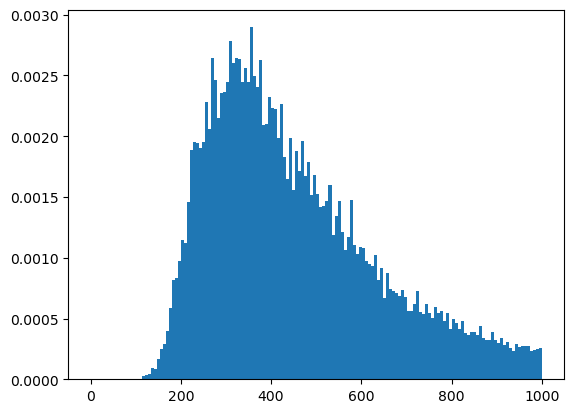

In [32]:
plt.hist(df['k_xylem_sat'], bins = 150, density= True);
plt.show()

In [ ]:
for var in org_cols:
    plt.hist(df[var], bins = 150, density= True);
    plt.savefig(f"hist{var}.png")
    plt.close()

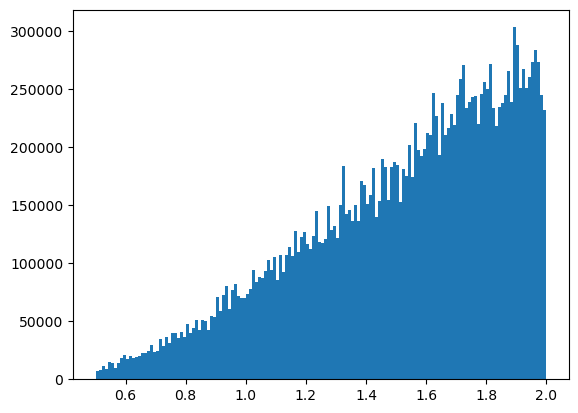

In [16]:
plt.hist(df['g1'], bins=150);

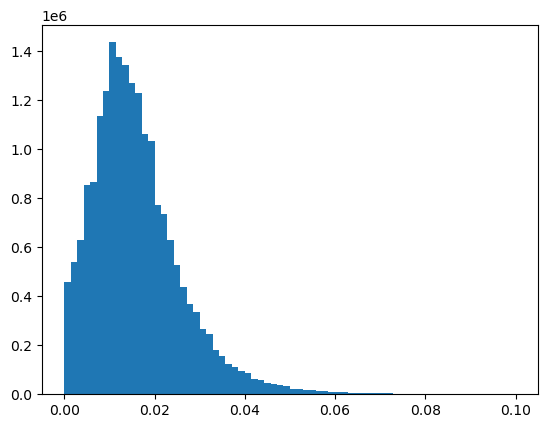

In [17]:
plt.hist(df['g0'], bins=70);
plt.savefig("test.png")

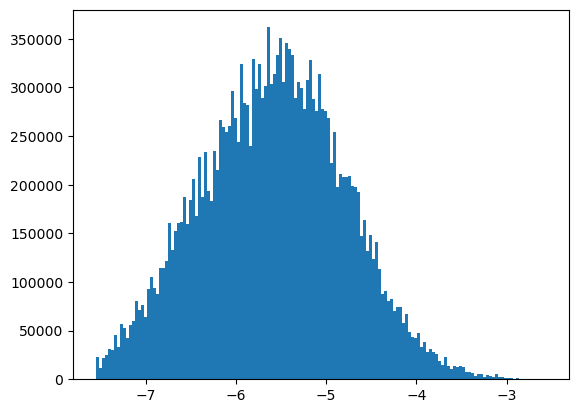

In [16]:
plt.hist(np.log10(df['k_soil_sat']) , bins = 150);

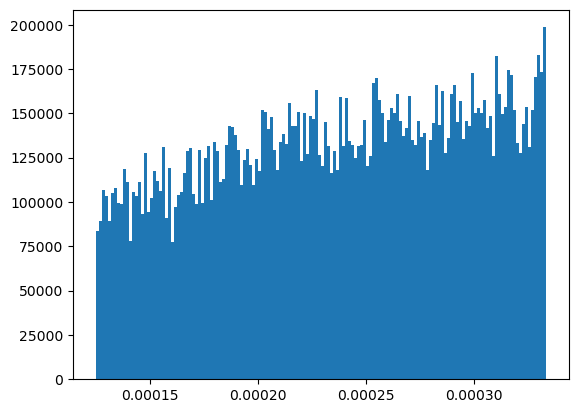

In [17]:
plt.hist(df['huber_value'] , bins = 150);

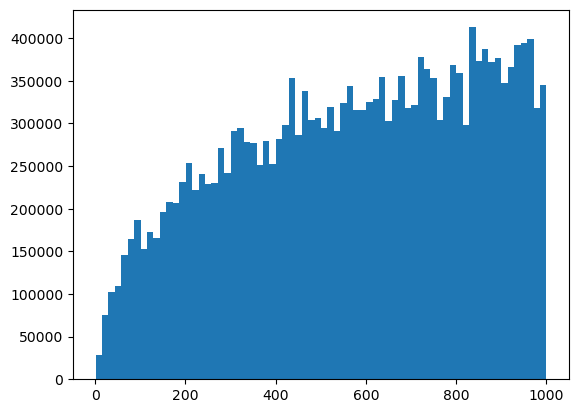

In [18]:
plt.hist(df['stem_hydraulic_capacitance'], bins = 70);

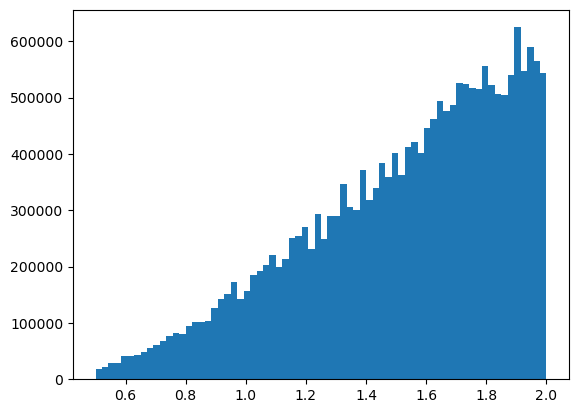

In [19]:
plt.hist(df['g1'], bins=70);

In [20]:
xi = pd.qcut(df['k_xylem_sat'],3)
df['i'] = xi
s = df['i'].unique()
for var in df.columns:
    print(var)
    if var == 'i':
        continue
    for si in s:
        dfs = df[df['i'] == si]
        data_fs = dfs[var]
        data = df[var]
        binwidth = (np.max(data)- np.min(data))/150
        plt.hist(data_fs,  bins=
    np.arange(np.min(data_fs), np.max(data_fs) + binwidth, binwidth),
                 alpha =0.5);
    plt.savefig(f"k_xylem_sat_{var}.png")
    plt.close()

Unnamed: 0.1
Unnamed: 0
stem_hydraulic_capacitance
k_xylem_sat
huber_value
leaf_hydraulic_capacitance
leaf_area_index
d_50_close
g0
g1
jackson_root_beta
k_soil_sat
tree_density
sand_frac
clay_frac
organic_matter_frac
LL
i


In [21]:
from scipy import stats
from itertools import combinations

In [24]:
l = list(combinations(org_cols, 2))

In [25]:
dA = []
for colX, colY in list(combinations(org_cols, 2)):
    print("L")
    dA.append([colX,colY, np.round(stats.spearmanr(df[colX], df[colY]).statistic, 3), 
               np.round(stats.spearmanr(df[colX], df[colY]).statistic, 3)**2])

L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L
L


KeyboardInterrupt: 

In [28]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout

In [1]:
pd.read_csv("/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/MCMC/fixed_ksat_regulation/Correlations.csv")

NameError: name 'pd' is not defined

In [1]:
exit()